In [ ]:
function polynomial_coeffs2val(x::Float64, coeffs::Vector{Float64}, center::Float64, range::Vector{Float64})
    # normalize the polynomial p(x), so that p(range[2]) = 1
    width = (range[2] - range[1]) / 2
    dx = (x - center) / width
    val = 0.0
    for i in 1:length(coeffs)
        val += coeffs[i] * dx^(i - 1)
    end
    return val
end
function polynomial_coeffs2val(x::Vector{Float64}, coeffs::Vector{Float64}, center::Float64, range::Vector{Float64})
    # normalize the polynomial p(x), so that p(range[2]) = 1
    width = (range[2] - range[1]) / 2
    vals = zeros(length(x))
    for j in 1:length(x)
        dx = (x[j] - center) / width
        val = 0.0
        for i in 1:length(coeffs)
            val += coeffs[i] * dx^(i - 1)
        end
        vals[j] = val
    end
    return vals
end

In [1]:
include("sampled_integrals.jl")
using Plots
using Printf
using BenchmarkTools
#using ProfileView
function exp2str(float_value::Float64, precision::Int=2)
    exponent = Int64(floor(log10(abs(float_value))))
    if exponent < 0
        if exponent < -precision
            f = Printf.Format("%0."*string(precision)*"e")
        else
            f = Printf.Format("%0."*string(precision)*"f")
        end
    else
        if exponent > precision
            f = Printf.Format("%0."*string(precision)*"e")
        else
            f = Printf.Format("%0."*string(max(precision-exponent ,1))*"f")
        end
    end
    return Printf.format(f, float_value)
end
function fprintln(args...; digits::Int64=2)
    # transform all args, if arg in args is a Float64, then transform it to a string with digits digits (default 2)
    new_args = []
    for arg in args
        if typeof(arg) == Float64
            push!(new_args, exp2str(arg, digits))
        else
            push!(new_args, arg)
        end
    end
    println(new_args...)
end


fprintln (generic function with 1 method)

In [2]:
# Test 
sample_order = 4
g0 = 2*pi*150/10^6  # 150Hz
delta_g = g0*0.20
delta0 = 0.0
delta_delta = 2*pi*0.1 # 100kHz 
sigmas = 3
N = 10^6

gaussian = (x, mu, sigma) -> exp(-(x-mu)^2/sigma^2/2)*1/sqrt(2*pi*sigma^2)

prob_fun_vec = [x -> gaussian(x, g0, delta_g), x -> gaussian(x, delta0, delta_delta)]
fun_vec = [x -> x*N*gaussian(x, g0, delta_g), x -> gaussian(x, delta0, delta_delta)] # g integral times g
range_vec = [[g0-sigmas*delta_g, g0+sigmas*delta_g], [-delta_delta*sigmas, delta_delta*sigmas]]

2-element Vector{Vector{Float64}}:
 [0.0003769911184307752, 0.0015079644737231008]
 [-1.8849555921538759, 1.8849555921538759]

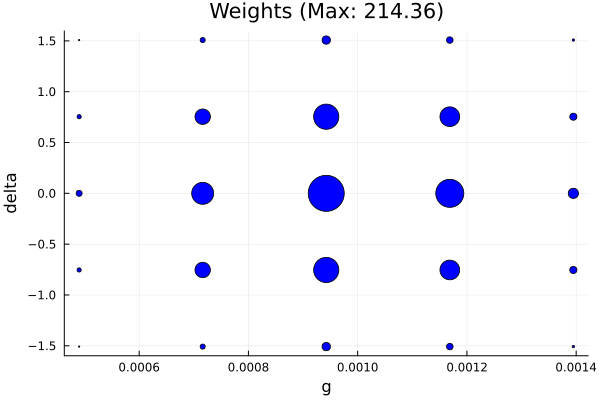

In [3]:
# Test
cube_locations, order_comb, centers = cubed_sample_grid(prob_fun_vec, range_vec, sample_order; on_borders=false, max_cum_order=0)
cube_weights, get_error, vals2coeffs, coeffs2vals = weights_and_errors(fun_vec, cube_locations, order_comb, centers, range_vec, reduced=true, fun_return=true)
plt = plot_weighted_locations_2D(cube_locations, cube_weights)
plot!(plt, xlabel="g", ylabel="delta", title="Weights (Max: "*string(round(maximum(cube_weights), digits=2))*")")

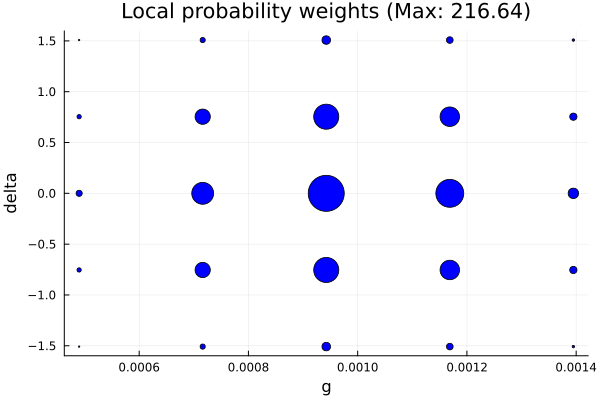

In [4]:
# create weights based on probability at extra_points
local_probability_weights = []
local_pdf_values = []
integrated_probability_weights = []
reltol=1e-6
if typeof(sample_order) == Int64
    sample_order_vec = [sample_order for i in 1:length(prob_fun_vec)]
else
    sample_order_vec = deepcopy(sample_order)
end
interval_integrals = []
all_limits = []
for i in 1:length(prob_fun_vec)
    how_many = sample_order_vec[i] + 2
    curr_limits = collect(range(range_vec[i][1], stop=range_vec[i][2], length=how_many))
    # interval based_integrals
    curr_pdf_integrals = [quadgk(x -> prob_fun_vec[i](x), curr_limits[j], curr_limits[j+1], rtol=reltol)[1] for j in 1:length(curr_limits)-1]
    curr_integrals = [quadgk(x -> fun_vec[i](x), curr_limits[j], curr_limits[j+1], rtol=reltol)[1] for j in 1:length(curr_limits)-1]
    curr_integrals = curr_integrals/sum(curr_pdf_integrals) # normalize to 1.0
    push!(interval_integrals, curr_integrals)
    push!(all_limits, curr_limits)
end
for i in 1:length(cube_locations)
    push!(local_probability_weights, prod([fun_vec[j](cube_locations[i][j]) for j in 1:length(cube_locations[i])]))
    push!(local_pdf_values, prod([prob_fun_vec[j](cube_locations[i][j]) for j in 1:length(cube_locations[i])]))
    # find the associated interval integral for each direction 
    curr_inds = zeros(Int64, length(cube_locations[i]))
    for j in 1:length(prob_fun_vec)
        dx = all_limits[j][2] - all_limits[j][1]
        curr_inds[j] = findfirst([(x + dx > cube_locations[i][j]) && (x < cube_locations[i][j]) for x in  all_limits[j]]) 
    end
    push!(integrated_probability_weights, prod([interval_integrals[j][curr_inds[j]] for j in 1:length(curr_inds)]))
end
# normalize local_probability_weights
local_probability_weights = local_probability_weights/sum(local_pdf_values)
# Now, let us plot the weights
plt = plot_weighted_locations_2D(cube_locations, local_probability_weights)
plot!(plt, xlabel="g", ylabel="delta", title="Local probability weights (Max: "*string(round(maximum(local_probability_weights), digits=2))*")")

In [5]:
plt = plot_weighted_locations_2D(cube_locations, integrated_probability_weights)
plot!(plt, xlabel="g", ylabel="delta", title="Integrated probability weights (Max: "*string(round(maximum(integrated_probability_weights), digits=2))*")")

MethodError: MethodError: no method matching plot_weighted_locations_2D(::Vector{Vector{Float64}}, ::Vector{Any})

Closest candidates are:
  plot_weighted_locations_2D(::Vector{Vector{Float64}}, !Matched::Vector{Float64}; plt, ms, kwargs...)
   @ Main c:\Users\micha\Desktop\PhD\Research\Projects\DD_Inhomogenously_Broadened_Spin_Ensemble\Julia\sampled_integrals.jl:366


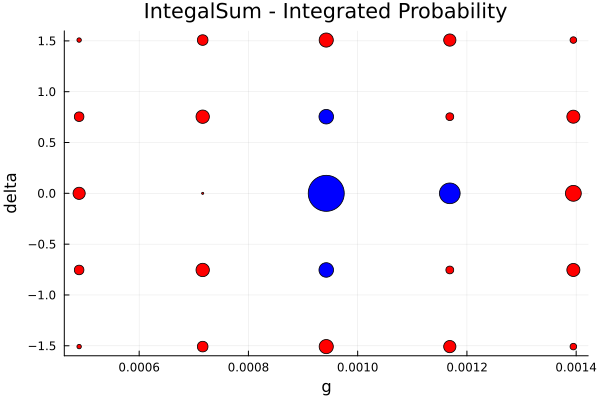

Max relative error: 0.099


In [6]:
#plot the weight differences
plt = plot_weighted_locations_2D(cube_locations, cube_weights - integrated_probability_weights)
max_rel_error = maximum(abs.(cube_weights - integrated_probability_weights))/maximum(abs.(cube_weights))
plot!(plt, xlabel="g", ylabel="delta", title="IntegalSum - Integrated Probability")
display(plt)
fprintln("Max relative error: ", max_rel_error, digits=3)

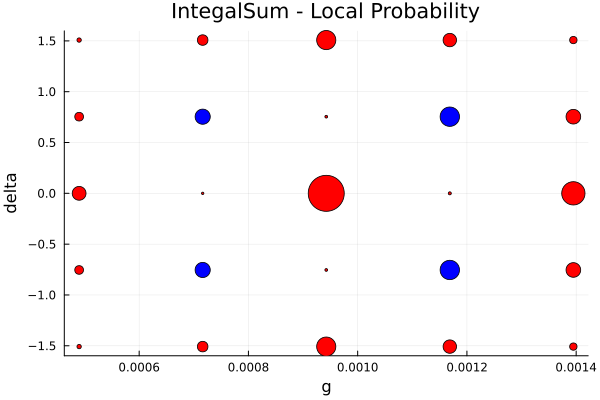

Max relative error: 0.011


In [7]:
#plot the weight differences
plt = plot_weighted_locations_2D(cube_locations, cube_weights - local_probability_weights)
max_rel_error = maximum(abs.(cube_weights - local_probability_weights))/maximum(abs.(cube_weights))
plot!(plt, xlabel="g", ylabel="delta", title="IntegalSum - Local Probability")
display(plt)
fprintln("Max relative error: ", max_rel_error, digits=3)

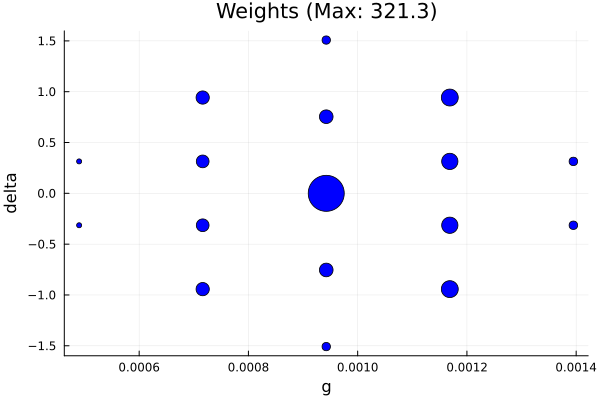

Order: 4
Number of points: 17
Needed points: 15
Extra points: 2


At threshold 0.99 there are 16 (of 17) points (94.12%) above threshold.


In [8]:
locations, order_comb, centers = sample_grid(prob_fun_vec, range_vec, sample_order; extra_points=0, symmetrize=true, reposition=true, on_borders=false, equidistant=true)
weights, get_error, vals2coeffs, coeffs2vals = weights_and_errors(fun_vec, locations, order_comb, centers, range_vec, reduced=true, fun_return=true)

plt = plot_weighted_locations_2D(locations, weights)
# xlabel g and ylabel delta
plot!(plt, xlabel="g", ylabel="delta", title="Weights (Max: "*string(round(maximum(weights), digits=2))*")")
# save plot in Plots folder
savefig(plt, "Plots/locations_order_"*string(sample_order)*"_sigmas_"*string(sigmas)*".png")
display(plt)
# how many extra extra points 
println("Order: ", sample_order)
println("Number of points: ", length(locations))
println("Needed points: ", length(order_comb))
println("Extra points: ", length(locations) - length(order_comb))
relative_weights = sort(abs.(weights)/maximum(abs.(weights)), rev=true)
cum_relative_weights = cumsum(relative_weights)
normalized_cum_relative_weights = cum_relative_weights/cum_relative_weights[end]
threshold = 0.99
weights_above_threshold = findfirst(x -> x > threshold, normalized_cum_relative_weights)
println("At threshold ", threshold, " there are ", weights_above_threshold, " (of ", length(relative_weights),") points (", round(weights_above_threshold/length(relative_weights)*100, digits=2), "%) above threshold.")

In [9]:
# Estimate distribution intrgral with these weights, the distirbution is given by a gaussian in 2D
factor_g, factor_delta = 2.0, 2.0
function gauss_2d_fun(x::Vector{Float64})
    mu = [g0, delta0]
    sigma = [delta_g*factor_g, delta_delta*factor_delta]
    Eta::Matrix = [1/sigma[1]^2 0; 0 1/sigma[2]^2]
    return exp(-1/2*transpose(x-mu)*Eta*(x-mu))/sqrt(2*pi)/sqrt(det(Eta))
end
function double_integral(funxy, range_vec, reltol)
    quadgk_integral = y -> quadgk(x -> funxy([x, y]), range_vec[1][1], range_vec[1][2], rtol=reltol)[1]
    quadgk_double_integral = quadgk(y -> quadgk_integral(y), range_vec[2][1], range_vec[2][2], rtol=reltol)[1]
    return quadgk_double_integral
end
# Estimate the integral
reltol = 1e-6
weighted_fun = x -> gauss_2d_fun(x)*prod([fun_vec[j](x[j]) for j in 1:length(x)])
integral_value = double_integral(weighted_fun, range_vec, reltol)
fprintln("QuadGK integral: ", integral_value, digits=5)
gauss_2d_fun_at_locations = [gauss_2d_fun(cube_locations[i]) for i in 1:length(cube_locations)]
gauss_2d_fun_at_reduced_locations = [gauss_2d_fun(locations[i]) for i in 1:length(locations)]
cube_integral_val = sum(cube_weights.*gauss_2d_fun_at_locations)
local_probability_val = sum(local_probability_weights.*gauss_2d_fun_at_locations)
integrated_probability_val = sum(integrated_probability_weights.*gauss_2d_fun_at_locations)
reduced_integrated_val = sum(weights.*gauss_2d_fun_at_reduced_locations)
fprintln("Integral_weights (Cube): " , cube_integral_val, digits=5)
fprintln("Integral_weights (Reduced): " , reduced_integrated_val, digits=5)
fprintln("Local probability weights: ", local_probability_val, digits=5)
fprintln("Integrated probability weights: ", integrated_probability_val, digits=5)
# Relative Errors 
println("="^50)
fprintln("Relative error (Cube): ", abs(cube_integral_val - integral_value)/abs(integral_value), digits=5)
fprintln("Relative error (Reduced): ", abs(reduced_integrated_val - integral_value)/abs(integral_value), digits=5)
fprintln("Relative error (Local probability): ", abs(local_probability_val - integral_value)/abs(integral_value), digits=5)
fprintln("Relative error (Integrated probability): ", abs(integrated_probability_val - integral_value)/abs(integral_value), digits=5)

QuadGK integral: 0.14227


Integral_weights (Cube): 0.14227
Integral_weights (Reduced): 0.14250
Local probability weights: 0.14284
Integrated probability weights: 0.13972


Relative error (Cube): 9.58263e-06
Relative error (Reduced): 0.00163
Relative error (Local probability): 0.00397
Relative error (Integrated probability): 0.01791


In [10]:
# Test 
operator_orders = [1,1,0]
sum_operator_orders = sum(operator_orders)
all_locations, all_orders, all_centers, all_range_vec, locations_ind = reduced_tensor_grid(operator_orders, prob_fun_vec, order_comb, locations, centers, range_vec; loc_ind=true, max_cum_order=6)
repeated_prob_fun_vec = repeat(prob_fun_vec, sum_operator_orders)
vals2coeffs, E_weights, G_ij = Ex_and_Varx(repeated_prob_fun_vec, all_locations, all_orders, all_centers, all_range_vec)
println("Number of points: ", length(all_locations))
println("Number of orders: ", length(all_orders))

Number of points: 289
Number of orders: 27


In [11]:
max_op_order = 4
max_num = length(locations)
order_to_weight_dict = all_operator_order_comb_weights(max_op_order, prob_fun_vec, order_comb, locations, centers, range_vec, max_cum_order=-1)

Dict{Vector{Int64}, Function} with 35 entries:
  [0, 1, 0] => Ex_and_Stdx_fun
  [1, 3, 0] => Ex_and_Stdx_fun
  [2, 1, 1] => Ex_and_Stdx_fun
  [2, 1, 0] => Ex_and_Stdx_fun
  [0, 0, 3] => Ex_and_Stdx_fun
  [0, 2, 1] => Ex_and_Stdx_fun
  [0, 1, 3] => Ex_and_Stdx_fun
  [0, 2, 0] => Ex_and_Stdx_fun
  [1, 0, 2] => Ex_and_Stdx_fun
  [0, 3, 1] => Ex_and_Stdx_fun
  [1, 1, 2] => Ex_and_Stdx_fun
  [0, 3, 0] => Ex_and_Stdx_fun
  [2, 2, 0] => Ex_and_Stdx_fun
  [0, 4, 0] => Ex_and_Stdx_fun
  [0, 0, 4] => Ex_and_Stdx_fun
  [0, 0, 2] => Ex_and_Stdx_fun
  [2, 0, 2] => Ex_and_Stdx_fun
  [4, 0, 0] => Ex_and_Stdx_fun
  [0, 1, 2] => Ex_and_Stdx_fun
  ⋮         => ⋮

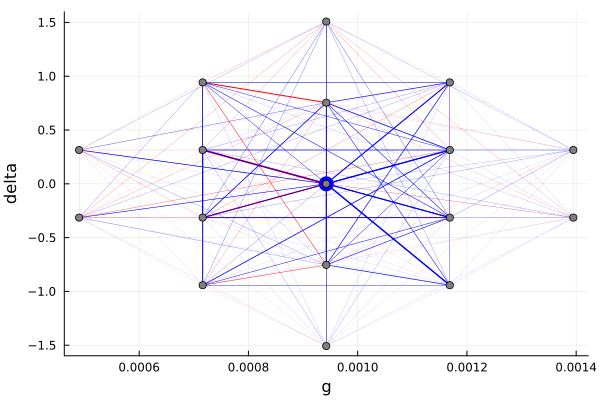

Operator Order: 2
Number of Considered Subsystems: 153 (of the naive 289 combinations 52.9%)
Needed Subsystems: 120 (41.5% of the naive combinations)
Extra Subsystems: 33
Sum of weights: 1.00 (sum-1.0=-2.52e-13)

"c:\\Users\\micha\\Desktop\\PhD\\Research\\Projects\\DD_Inhomogenously_Broadened_Spin_Ensemble\\Julia\\Plots\\mutli_locations_weighted_Fidelity_order_4_sigmas_3.png"

In [13]:
# For n dimensional fidelities, we need to generate a tensor grid of locations, using mgreater_range based
operator_order = 2
all_locations, all_orders, all_orders_integrals, all_centers, all_range_vec, locations_ind = reduced_tensor_grid(operator_order, prob_fun_vec, order_comb, locations, centers, range_vec, max_cum_order=0, reltol=1e-6)
weights, get_error, vals2coeffs, coeffs2vals = weights_and_errors(all_orders_integrals, all_locations, all_orders, all_centers, all_range_vec)

# make xaxis logarithmic
n_locations = length(locations)
n_all_locations = length(all_locations)
println("Operator Order: ", operator_order)
println("Number of Considered Subsystems: ", n_all_locations, " (of the naive "*string(n_locations^operator_order)*" combinations "*exp2str(n_all_locations/n_locations^operator_order*100)*"%)")
println("Needed Subsystems: ", length(all_orders), " ("*exp2str(length(all_orders)/n_locations^operator_order*100)*"% of the naive combinations)")
println("Extra Subsystems: ", n_all_locations - length(all_orders))
fprintln("Sum of weights: ", sum(weights), " (sum-1.0=", sum(weights)-1.0,")")

# print the weights as lines between the 2d points
plt = plot()
# first the points
# then the lines (color for sign of weight) and thinckness for weight
max_weight = maximum(abs.(weights))
max_thickness = 15
for i in 1:length(weights)
    w = weights[i]
    curr_loc = all_locations[i]
    loc1 = curr_loc[1:2:end]
    loc2 = curr_loc[2:2:end]
    color_str = "blue"
    if w < 0
        color_str = "red"
    end
    plot!(plt, loc1, loc2, color=color_str, lw=abs(w)/max_weight*max_thickness, label=nothing)
end
scatter!(plt, [l[1] for l in locations], [l[2] for l in locations], label=nothing, color="gray")
plot!(plt, xlabel="g", ylabel="delta")
display(plt)
savefig(plt, "Plots/mutli_locations_weighted_Fidelity_order_"*string(sample_order)*"_sigmas_"*string(sigmas)*".png")

In [14]:
all_orders

120-element Vector{Vector{Int64}}:
 [0, 0, 0, 0]
 [0, 0, 0, 1]
 [0, 0, 0, 2]
 [0, 0, 0, 3]
 [0, 0, 0, 4]
 [0, 0, 1, 0]
 [0, 0, 1, 1]
 [0, 0, 1, 2]
 [0, 0, 1, 3]
 [0, 0, 2, 0]
 ⋮
 [2, 2, 3, 0]
 [2, 2, 3, 1]
 [2, 2, 4, 0]
 [3, 0, 3, 0]
 [3, 0, 3, 1]
 [3, 0, 4, 0]
 [3, 1, 3, 1]
 [3, 1, 4, 0]
 [4, 0, 4, 0]

In [ ]:
function better_weighted_sample_sum(fun::Function, pdf::Function, locations::Vector{Float64}, borders::Vector{Float64})
    # use integral over intervals for probabilities
    locations = sort(locations)
    borders = sort(borders)
    min_val = borders[1]
    max_val = borders[2]
    interval_borders = [min_val]
    for i in 1:length(locations)-1
        push!(interval_borders, (locations[i] + locations[i+1])/2)
    end
    push!(interval_borders, max_val)
    # get the pdf weights
    interval_weights = zeros(length(interval_borders)-1)
    for i in 1:length(interval_borders)-1
        interval_weights[i] = quadgk(pdf, interval_borders[i], interval_borders[i+1])[1]
    end
    interval_weights = interval_weights/sum(interval_weights)
    # get the function values 
    fun_values = fun.(locations)
    # get the weighted sum
    weighted_sum = sum(fun_values .* interval_weights)
    return weighted_sum
end

function better_weighted_sample_sum(fun::Function, pdf::Vector{Function}, locations::Vector{Vector{Float64}}, borders::Vector{Vector{Float64}})
    dim = length(pdf)
    if dim > 1
        error("dim > 1 is not implemented yet")
    end
    locs = [l[1] for l in locations]
    return better_weighted_sample_sum(fun, pdf[1], locs, borders[1])
end


better_weighted_sample_sum (generic function with 3 methods)

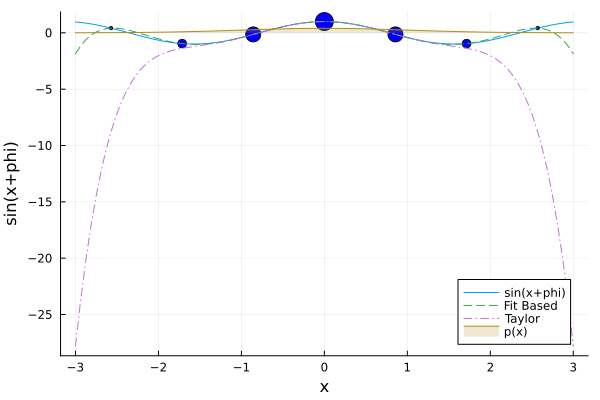

Integral value: 0.13
Difference in integral (Approx.): 0.29
Difference in integral (Interpolated): 1.32e-03
Improvement: 220.2
Difference in integral (Naive Weighted Sample_Sum): 7.57e-03
Improvement: 5.71
Difference in integral (Better Weighted Sample_Sum): 0.12
Improvement: 87.7


In [ ]:
# Do Taylor around the center point get taylor coefficients of fun around center by using the derivative 
function Taylor2order_sin(phi::Float64, freq::Float64, center::Float64, order::Int64, range::Vector{Float64})
    funcircle = [x -> sin(x*freq+phi), x-> cos(x*freq+phi), x -> -sin(x*freq+phi), x -> -cos(x*freq+phi)]
    width = (range[2] - range[1])/2
    coeffs = zeros(order+1)
    coeffs[1] = funcircle[1](center)
    for i in 1:order
        curr_index = (i % 4) + 1
        coeffs[i+1] = funcircle[curr_index](center)/factorial(i) * width^i * freq^i
    end
    return coeffs
end

# test function in 1D
reltol = 1e-6
dist_freq = 1.0
phi = pi/2
freq = 2.0
fun = x -> sin(x*freq+phi)
oned_fun_vec::Vector{Function} = [x -> gaussian(x, 0.0, dist_freq)]
dx = 3.0
range_vec = [[-dx, dx]]
order = 6
locations, order_comb, centers = sample_grid(oned_fun_vec, range_vec, order; symmetrize=true, on_borders=false, extra_points=0)
#locations = [[l] for l in collect(range(centers[1]-dx, centers[1]+dx, length=order+1))]
weights, get_error, vals2coeffs, coeffs2vals = weights_and_errors(oned_fun_vec, locations, order_comb, centers, range_vec)

# plot the sinus, the sample points along the line, and the extrapolated function 
plt = plot()
x = collect(range(range_vec[1][1], range_vec[1][2], length=100))
plot!(plt, x, fun.(x), label="sin(x+phi)")
f_loc = [fun(l[1]) for l in locations]
# add color for sign of weight and size for weight
colors = [w>0 ? "blue" : "red" for w in weights]
radiuss = [sqrt(abs(w)) for w in weights]
radiuss *= 10/maximum(radiuss)
scatter!(plt, [l[1] for l in locations], f_loc, label=nothing, color=colors, ms=radiuss)
# Plot estimate using: polynomial_coeffs2val(x::Float64, coeffs::Vector{Float64}, center::Float64, range::Vector{Float64})
coeffs = vals2coeffs*f_loc
est_vals = polynomial_coeffs2val(x, coeffs, centers[1], range_vec[1])
# plot dashed
plot!(plt, x, est_vals, label="Fit Based", linestyle=:dash)

taylor_coeffs = Taylor2order_sin(phi, freq, centers[1], order, range_vec[1])
taylor_vals = polynomial_coeffs2val(x, taylor_coeffs, centers[1], range_vec[1])
sample_weights = oned_fun_vec[1].(x)
plot!(plt, x, taylor_vals, label="Taylor", linestyle=:dashdot)
plot!(plt, x, sample_weights, fillrange=zeros(length(sample_weights)), fillalpha=0.2, label="p(x)")
plot!(plt, xlabel="x", ylabel="sin(x+phi)")
# Save plot
savefig(plt, "Plots/Taylor_sin_order_"*string(order)*"_sigmas_"*string(Int64(dx/dist_freq))*".png")
display(plt)

int_weighted = quadgk(x -> fun(x) * oned_fun_vec[1](x), range_vec[1][1], range_vec[1][2], rtol=reltol)[1]
approx_int_weighted = quadgk(x -> polynomial_coeffs2val(x, taylor_coeffs, centers[1], range_vec[1]) * oned_fun_vec[1](x), range_vec[1][1], range_vec[1][2], rtol=reltol)[1]
interpolated_int_weighted = quadgk(x -> polynomial_coeffs2val(x, coeffs, centers[1], range_vec[1]) * oned_fun_vec[1](x), range_vec[1][1], range_vec[1][2], rtol=reltol)[1]
difference_sum_approx = abs(int_weighted - approx_int_weighted)
difference_sum_interpolated = abs(int_weighted - interpolated_int_weighted)
fprintln("Integral value: ", int_weighted)
fprintln("Difference in integral (Approx.): ", difference_sum_approx)
fprintln("Difference in integral (Interpolated): ", difference_sum_interpolated)
fprintln("Improvement: ", difference_sum_approx/difference_sum_interpolated)

# Samples at sample points with probability based weight?
approximate_sample_integral = weighted_sample_sum(fun, oned_fun_vec, locations)
naive_difference_sum = abs(abs(int_weighted - approximate_sample_integral)/int_weighted)
fprintln("Difference in integral (Naive Weighted Sample_Sum): ", naive_difference_sum)
fprintln("Improvement: ", naive_difference_sum/difference_sum_interpolated)
approximate_sample_integral = better_weighted_sample_sum(fun, oned_fun_vec, locations, range_vec)
naive_difference_sum = abs(abs(int_weighted - approximate_sample_integral)/int_weighted)
fprintln("Difference in integral (Better Weighted Sample_Sum): ", naive_difference_sum)
fprintln("Improvement: ", naive_difference_sum/difference_sum_interpolated)

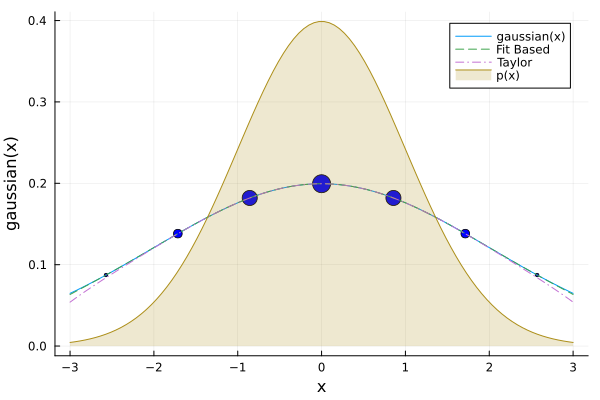

Integral value: 0.18
Difference in integral (Approx.): 5.83e-04
Difference in integral (Interpolated): 4.01e-06
Improvement: 145.6
Difference in integral (Naive Weighted Sample_Sum): 4.18e-04
Improvement: 104.4
Difference in integral (Better Weighted Sample_Sum): 5.98e-03
Improvement: 1.49e+03


In [ ]:
function Taylor2order_gaussian(freq::Float64, order::Int64, range::Vector{Float64})
    width = (range[2] - range[1])/2
    coeffs = zeros(order+1)
    val = gaussian(0.0, 0.0, 1/freq)
    coeffs[1] = val
    curr_num = 1.0
    for i in 1:order
        curr_index = (i % 4) + 1
        pref = width^i
        if i % 2 == 1
            coeffs[i+1] = 0.0
        else
            curr_num *= i
            if i % 4 == 0
                curr_sign = 1.0
            else
                curr_sign = -1.0
            end
            #println( curr_sign * curr_num)
            coeffs[i+1] = curr_sign * pref * val * (freq^i) / curr_num
        end
    end
    return coeffs
end
# Do Taylor around the center point get taylor coefficients of fun around center by using the derivative 
# test function in 1D
reltol = 1e-10
dist_freq = 1.0
freq =2.0
fun = x -> gaussian(x, 0.0, freq)
oned_fun_vec::Vector{Function} = [x -> gaussian(x, 0.0, dist_freq)]
dx = 3.0
range_vec = [[-dx, dx]]
order = 6
locations, order_comb, centers = sample_grid(oned_fun_vec, range_vec, order; symmetrize=true, on_borders=false, extra_points=0)
#locations = [[l] for l in collect(range(centers[1]-dx, centers[1]+dx, length=order+1))]
weights, get_error, vals2coeffs, coeffs2vals = weights_and_errors(oned_fun_vec, locations, order_comb, centers, range_vec)

# plot the sinus, the sample points along the line, and the extrapolated function 
plt = plot()
x = collect(range(range_vec[1][1], range_vec[1][2], length=100))
plot!(plt, x, fun.(x), label="gaussian(x)")
f_loc = [fun(l[1]) for l in locations]
# add color for sign of weight and size for weight
colors = [w>0 ? "blue" : "red" for w in weights]
radiuss = [sqrt(abs(w)) for w in weights]
radiuss *= 10/maximum(radiuss)
scatter!(plt, [l[1] for l in locations], f_loc, label=nothing, color=colors, ms=radiuss)
# Plot estimate using: polynomial_coeffs2val(x::Float64, coeffs::Vector{Float64}, center::Float64, range::Vector{Float64})
coeffs = vals2coeffs*f_loc
est_vals = polynomial_coeffs2val(x, coeffs, centers[1], range_vec[1])
# plot dashed
plot!(plt, x, est_vals, label="Fit Based", linestyle=:dash)

taylor_coeffs = Taylor2order_gaussian(1/freq, order, range_vec[1])
taylor_vals = polynomial_coeffs2val(x, taylor_coeffs, centers[1], range_vec[1])
sample_weights = oned_fun_vec[1].(x)
plot!(plt, x, taylor_vals, label="Taylor", linestyle=:dashdot)
plot!(plt, x, sample_weights, fillrange=zeros(length(sample_weights)), fillalpha=0.2, label="p(x)")
plot!(plt, xlabel="x", ylabel="gaussian(x)")
# Save plot
savefig(plt, "Plots/Taylor_gauss_order_"*string(order)*"_sigmas_"*string(Int64(dx/dist_freq))*".png")
display(plt)

weight = quadgk(x -> oned_fun_vec[1](x), range_vec[1][1], range_vec[1][2], rtol=reltol)[1]
int_weighted = quadgk(x -> fun(x) * oned_fun_vec[1](x)/weight, range_vec[1][1], range_vec[1][2], rtol=reltol)[1]
approx_int_weighted = quadgk(x -> polynomial_coeffs2val(x, taylor_coeffs, centers[1], range_vec[1]) * oned_fun_vec[1](x)/weight, range_vec[1][1], range_vec[1][2], rtol=reltol)[1]
interpolated_int_weighted = quadgk(x -> polynomial_coeffs2val(x, coeffs, centers[1], range_vec[1]) * oned_fun_vec[1](x)/weight, range_vec[1][1], range_vec[1][2], rtol=reltol)[1]
difference_sum_approx = abs(abs(int_weighted - approx_int_weighted)/int_weighted)
difference_sum_interpolated = abs(abs(int_weighted - interpolated_int_weighted)/int_weighted)
fprintln("Integral value: ", int_weighted)
fprintln("Difference in integral (Approx.): ", difference_sum_approx)
fprintln("Difference in integral (Interpolated): ", difference_sum_interpolated)
fprintln("Improvement: ", difference_sum_approx/difference_sum_interpolated)

# Samples at sample points with probability based weight?
approximate_sample_integral = weighted_sample_sum(fun, oned_fun_vec, locations)
naive_difference_sum = abs(abs(int_weighted - approximate_sample_integral)/int_weighted)
fprintln("Difference in integral (Naive Weighted Sample_Sum): ", naive_difference_sum)
fprintln("Improvement: ", naive_difference_sum/difference_sum_interpolated)
approximate_sample_integral = better_weighted_sample_sum(fun, oned_fun_vec, locations, range_vec)
naive_difference_sum = abs(abs(int_weighted - approximate_sample_integral)/int_weighted)
fprintln("Difference in integral (Better Weighted Sample_Sum): ", naive_difference_sum)
fprintln("Improvement: ", naive_difference_sum/difference_sum_interpolated)

In [ ]:
# A function that creates reduced tensor grids for different orders, 

In [44]:
Ex_Stdx_fun = get_Ex_and_Stdx_fun(oned_fun_vec, locations, order_comb, centers, range_vec)
Ex, Stdx = Ex_Stdx_fun(f_loc)
println("Expectation Value (Ex): ", Ex)
println("Standard Deviation (Stdx): ", Stdx)

Expectation Value (Ex): 0.1782696398671542
Standard Deviation (Stdx): 0.026448384171755435


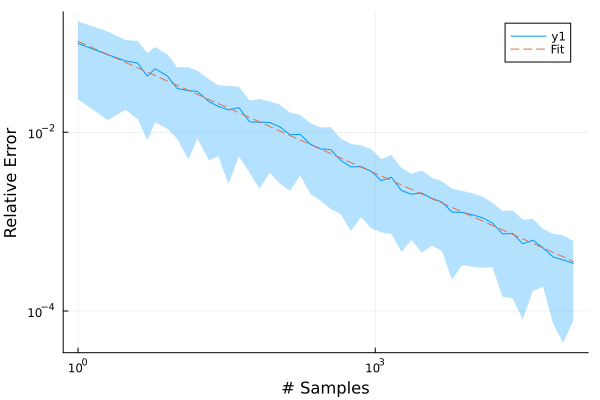

Estimated Samples to accuracy: 9.27e+08


In [27]:
using Statistics
rng = MersenneTwister(1234)
how_many_subsets = 100
subset_sizes = Vector{Int64}(unique(floor.(10 .^(collect(LinRange(0, 5, 50))))))
mean_vals = zeros(Float64, length(subset_sizes))
std_vals = zeros(Float64, length(subset_sizes))
for (i, subset_size) in enumerate(subset_sizes)
    vals = samples_of_samples(fun, [0.0], [1/dist_freq], how_many_subsets, subset_size; bounds=range_vec, rng=rng)
    mean_vals[i] = mean(abs.(abs.(vals .- int_weighted)/int_weighted))
    std_vals[i] = std(abs.(abs.(vals .- int_weighted)/int_weighted))
end
# Plot
plt = plot()
# Area plot from mean-std to mean+std
plot!(plt, subset_sizes, mean_vals, ribbon=std_vals, fillalpha=0.3, yscale=:log10, xscale=:log10)
plot!(plt, xlabel="# Samples", ylabel="Relative Error")

# fit to A/x^B
using Optim
# weight the fit via the std
function Fit_fun(param)
    A = param[1]
    B = param[2]
    return sum(abs.((A./subset_sizes.^B) .- mean_vals)./std_vals)
end
result = optimize(Fit_fun, [1.0, 1.0])
optimized_params = Optim.minimizer(result)
#fprintln("Optimized params: ", optimized_params)
# Plot the fit function
plot!(plt, subset_sizes, optimized_params[1]./subset_sizes.^optimized_params[2], label="Fit", linestyle=:dash)
display(plt)
# Extrapolated, how many samples are required to reach the error of the interpolation
extrapolated_samples = (optimized_params[1]/difference_sum_interpolated)^(1/optimized_params[2])	
fprintln("Estimated Samples to accuracy: ", extrapolated_samples)